In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
def convert_to_timestamp(date_str):
    dt = datetime.fromisoformat(date_str)
    timestamp = int(dt.timestamp() * 1000)
    return timestamp

In [3]:
df_code = pd.read_csv("../../data/workloads/Azure/Azure_code.csv")
print(len(df_code))
print(df_code.columns)
print(df_code["ContextTokens"].mean())
print(df_code['GeneratedTokens'].mean())
print(df_code["ContextTokens"].max())
print(df_code['GeneratedTokens'].max())
df_code["TotalTokens"] = df_code["ContextTokens"] + df_code["GeneratedTokens"]
print(df_code["TotalTokens"].mean())
print(df_code["TotalTokens"].max())
df_code['timestamp'] = df_code['TIMESTAMP'].apply(convert_to_timestamp)

16803695
Index(['TIMESTAMP', 'ContextTokens', 'GeneratedTokens'], dtype='object')
2511.27569103105
22.689729967129253
7743
5000
2533.965420998179
12691


In [4]:
df_conv = pd.read_csv("../../data/workloads/Azure/Azure_conv.csv")
print(len(df_conv))
print(df_conv.columns)
print(df_conv["ContextTokens"].mean())
print(df_conv['GeneratedTokens'].mean())
print(df_conv["ContextTokens"].max())
print(df_conv['GeneratedTokens'].max())
df_conv["TotalTokens"] = df_conv["ContextTokens"] + df_conv["GeneratedTokens"]
print(df_conv["TotalTokens"].mean())
print(df_conv["TotalTokens"].max())
df_conv['timestamp'] = df_conv['TIMESTAMP'].apply(convert_to_timestamp)

27303999
Index(['TIMESTAMP', 'ContextTokens', 'GeneratedTokens'], dtype='object')
1631.579539612494
105.5091875003365
7999
1500
1737.0887271128306
9158


In [5]:
time_window = 30 * 60 * 1000

In [6]:
df_code['TimeWindow'] = (df_code['timestamp'] // time_window) * time_window
grouped_code = df_code.groupby('TimeWindow').agg({
        'ContextTokens': 'sum',
        'GeneratedTokens': 'sum'
}).reset_index()

In [7]:
df_conv['TimeWindow'] = (df_conv['timestamp'] // time_window) * time_window
grouped_conv = df_conv.groupby('TimeWindow').agg({
        'ContextTokens': 'sum',
        'GeneratedTokens': 'sum'
}).reset_index()

In [8]:
df = pd.read_csv("../../data/datasets/ShareGPT/cleaned.csv")
print(len(df))
print(df.columns)
prompt_tokens = sorted(df['prompt_lens'])
response_tokens = sorted(df['response_lens'])
prompt_tokens = prompt_tokens[int(len(prompt_tokens) * 0.05):int(len(prompt_tokens) * 0.95)]
response_tokens = response_tokens[int(len(response_tokens) * 0.05):int(len(response_tokens) * 0.95)]
print(np.min(prompt_tokens), np.max(prompt_tokens))
print(np.min(response_tokens), np.max(response_tokens))

92641
Index(['prompts', 'completions', 'prompt_lens', 'response_lens'], dtype='object')
7 911
5 632


Value Range of ContextTokens: 6499.676111111111 - 231306.8061111111 - 34210.03888888889 - 119388.67666666667
Mean of ContextTokens: 69773.00061673281 - 73658.47572420635
Value Range of GeneratedTokens: 54.88 - 1912.7911111111111 - 2435.443333333333 - 7515.094444444445
Mean Value:  630.4088988095239 4763.265128968254


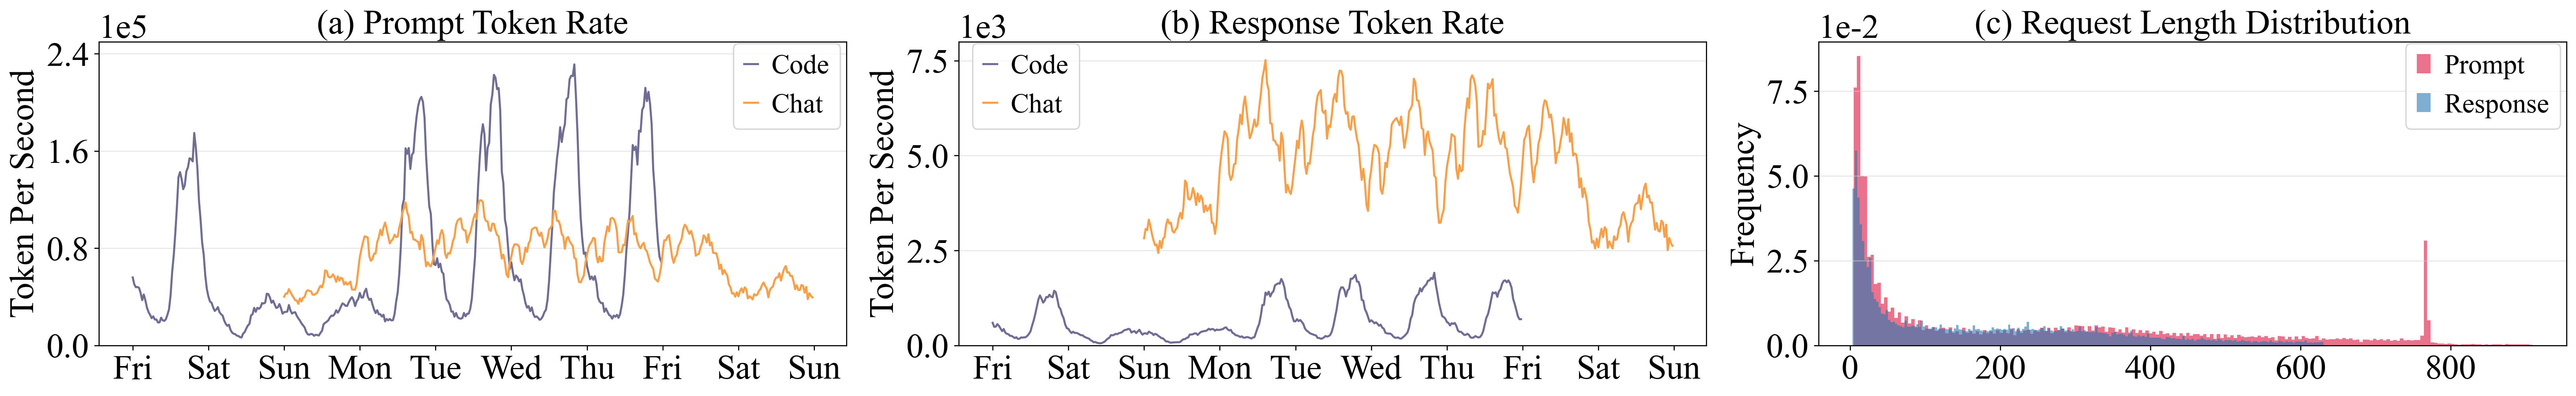

In [12]:
from matplotlib.ticker import ScalarFormatter

def plot_workload(original_workload1, original_workload2):
    workload1 = original_workload1.copy()
    workload2 = original_workload2.copy()
    workload1["TimeWindow"] = pd.to_datetime(workload1["TimeWindow"], unit='ms')
    workload2["TimeWindow"] = pd.to_datetime(workload2["TimeWindow"], unit='ms')

    workload1['ContextTokens'] = workload1['ContextTokens'] / (time_window // 1000)
    workload1['GeneratedTokens'] = workload1['GeneratedTokens'] / (time_window // 1000)
    workload2['ContextTokens'] = workload2['ContextTokens'] / (time_window // 1000)
    workload2['GeneratedTokens'] = workload2['GeneratedTokens'] / (time_window // 1000)

    colors = ["#706d94", "#F7A049"]
    labels = [
        "Code",
        "Chat"
    ]
    plt.rcParams.update({'font.size': 25, "font.family": 'Times New Roman'})
    row, col = 1, 3
    scale = 2.66
    fig, axes = plt.subplots(nrows=row, ncols=col, figsize=(scale * 4 * col + 0.2 * (col-1), 4), dpi=250)
    fig.subplots_adjust(wspace=0.15, hspace=0.4)
    plt.rcParams.update({'font.size': 25, "font.family": 'Times New Roman'})

    print(f"Value Range of ContextTokens: {workload1['ContextTokens'].min()} - {workload1['ContextTokens'].max()} - {workload2['ContextTokens'].min()} - {workload2['ContextTokens'].max()}")
    print(f"Mean of ContextTokens: {workload1['ContextTokens'].mean()} - {workload2['ContextTokens'].mean()}")
    axes[0].plot(workload1["TimeWindow"], workload1["ContextTokens"], color=colors[0], label=labels[0])
    axes[0].plot(workload2["TimeWindow"], workload2["ContextTokens"], color=colors[1], label=labels[1])
    axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%a'))
    # for tick in axes[0].xaxis.get_major_ticks():
        # tick.label.set_fontsize(20)
    # axes[0].set_xlabel('Timeline')
    axes[0].set_ylabel('Token Per Second')
    axes[0].tick_params(axis='y')
    axes[0].set_title("(a) Prompt Token Rate", fontsize=25)
    axes[0].grid(color='lightgray', axis="y", zorder=1, alpha=0.5)
    axes[0].set_ylim(0, 250000)
    # axes[0].set_ylim(-10000, 250000)
    axes[0].set_yticks([0, 80000, 160000, 240000])
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].legend(loc='upper right', prop={'size': 20}, bbox_to_anchor=(1.01, 1.04), handlelength=0.5, handletextpad=0.5)

    # axes[0].get_yaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))
    # axes[0].get_yaxis().get_offset_text().set_position((1, 1))
    # axes[0].get_yaxis().get_offset_text().set_fontsize(20) 
    # axes[0].set_yscale('log')

    print(f"Value Range of GeneratedTokens: {workload1['GeneratedTokens'].min()} - {workload1['GeneratedTokens'].max()} - {workload2['GeneratedTokens'].min()} - {workload2['GeneratedTokens'].max()}")
    print(f"Mean Value: ", workload1['GeneratedTokens'].mean(), workload2['GeneratedTokens'].mean())
    axes[1].plot(workload1["TimeWindow"], workload1["GeneratedTokens"], color=colors[0], label=labels[0])
    axes[1].plot(workload2["TimeWindow"], workload2["GeneratedTokens"], color=colors[1], label=labels[1])
    axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%a'))
    # for tick in axes[1].xaxis.get_major_ticks():
        # tick.label.set_fontsize(20)
    # axes[1].set_xlabel('Timeline')
    # axes[1].set_ylabel('tokens')
    axes[1].set_title("(b) Response Token Rate", fontsize=25)
    axes[1].tick_params(axis='y')
    axes[1].grid(color='lightgray', axis="y", zorder=1, alpha=0.5)
    axes[1].set_ylabel('Token Per Second')
    # axes[1].set_ylim(-500, 8000)
    axes[1].set_ylim(0, 8000)
    axes[1].set_yticks([0, 2500, 5000, 7500])
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].legend(loc='upper left', prop={'size': 20}, bbox_to_anchor=(0, 1.04), handlelength=0.5, handletextpad=0.5)
    # axes[1].set_yscale('log')

    hist1, bins1 = np.histogram(prompt_tokens, bins=200)
    hist2, bins2 = np.histogram(response_tokens, bins=200)
    hist1 = hist1 / len(prompt_tokens)
    hist2 = hist2 / len(response_tokens)
    axes[2].set_ylabel('Frequency')
    axes[2].bar(bins1[:-1], hist1, width=np.diff(bins1), color=(0.863, 0.078, 0.235), label="Prompt", alpha=0.6)
    axes[2].bar(bins2[:-1], hist2, width=np.diff(bins2), color="#2878B5", label="Response", alpha=0.6)
    # axes[2].bar(bins1[:-1], hist1, width=diff(bins1), color=(0.863, 0.078, 0.235), label="Prompt", alpha=0.5)
    # axes[2].bar(bins2[:-1], hist2, color="#2878B5", label="Response", alpha=0.5)
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_title("(c) Request Length Distribution", fontsize=25)
    axes[2].grid(color='lightgray', axis="y", zorder=1, alpha=0.5)
    axes[2].legend(loc='upper right', prop={'size': 20}, bbox_to_anchor=(1.01, 1.04), handlelength=0.5, handletextpad=0.5)
    # axes[2].legend(loc='upper left', prop={'size': 20}, bbox_to_anchor=(0.12, 1.04), handlelength=0.5, handletextpad=0.5)
    # plt.legend(loc=4, prop={'size': 14})
    plt.savefig("motivation_study.pdf", bbox_inches='tight')


plot_workload(grouped_code, grouped_conv)